In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

df = pd.read_csv("../../../data/insurance.csv")

X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_features = ["age", "bmi", "children"]
cat_features = ["sex", "smoker", "region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

rf = RandomForestRegressor(random_state=42)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", rf)
])

param_grid = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__max_depth": [None, 5, 10, 20],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best params:", grid.best_params_)

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.4f}")

Best params: {'regressor__max_depth': 5, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 200}
MAE:  2488.02
RMSE: 4343.17
R2:   0.8785


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.tree import plot_tree

rf_model_internal = best_model.named_steps['regressor']

ohe_feature_names = best_model.named_steps['preprocessor']\
                    .named_transformers_['cat']\
                    .get_feature_names_out(cat_features)
all_feature_names = np.concatenate([num_features, ohe_feature_names])

In [ ]:
import wandb


run = wandb.init(
    project="Medical-Insurance-Cost-Prediction", 
    name="RandomForestRegressor", 
    config={
        "model": "RandomForestRegressor",
        "C": 1.0,
        "cv_folds": 5,
        "max_iter": 1000,
        "test_size": 0.2,
        "random_state": 42
    }
)

print(run.config)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

NameError: name 'wandb' is not defined

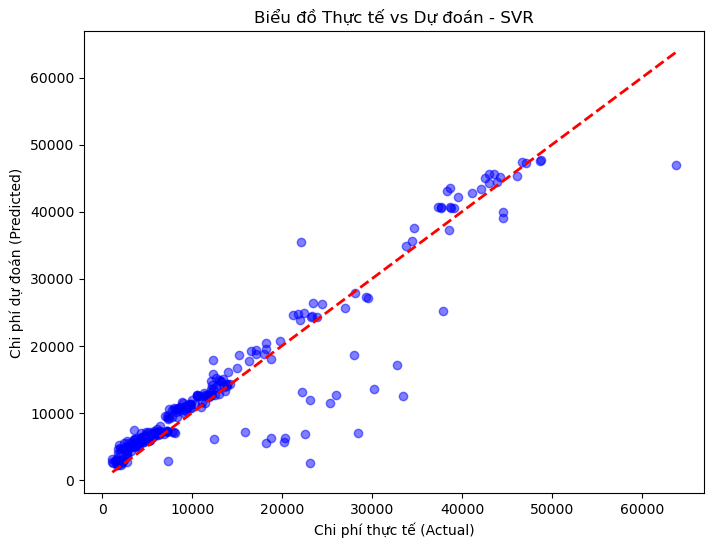

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.5, color='blue')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Đường chuẩn y=x
ax.set_xlabel('Chi phí thực tế (Actual)')
ax.set_ylabel('Chi phí dự đoán (Predicted)')
ax.set_title('Biểu đồ Thực tế vs Dự đoán - SVR')

wandb.log({
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Actual_vs_Predicted": wandb.Image(fig)
})

plt.close(fig)

C:\Users\03358\AppData\Local\Temp\ipykernel_6608\1633249308.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


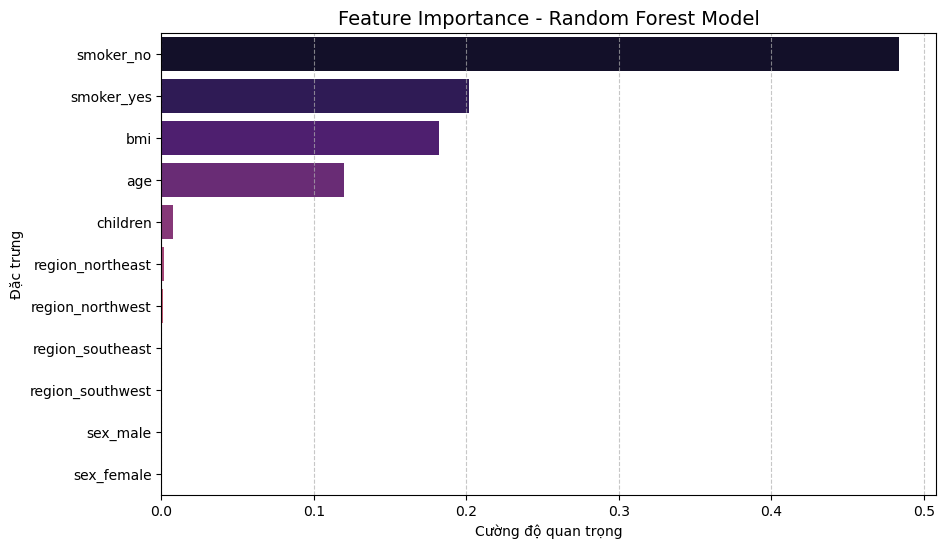

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

rf_model = best_model.named_steps['regressor']

preprocessor = best_model.named_steps['preprocessor']
cat_encoder = preprocessor.named_transformers_['cat']
cat_features_transformed = cat_encoder.get_feature_names_out(cat_features)
all_feature_names = num_features + list(cat_features_transformed)

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Feature Importance - Random Forest Model', fontsize=14)
plt.xlabel('Cường độ quan trọng')
plt.ylabel('Đặc trưng')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import os
import joblib
import datetime


metadata = {
    "model_name": "Random Forest Regressor",
    "version": "1.0",
    "date_created": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "metrics": {
        "r2": r2,
        "mae": mae,
        "rmse": rmse
    },
    "features": list(X_train.columns)
}


model_package = {
    "pipeline": best_model,
    "metadata": metadata
}

current_dir = os.path.abspath('')

project_root = os.path.dirname(os.path.dirname(current_dir))
save_dir = os.path.join(project_root, 'models')


os.makedirs(save_dir, exist_ok=True)


joblib_path = os.path.join(save_dir, 'random_forest_regressor_pipeline.joblib')
joblib.dump(model_package, joblib_path)

print(f"\n✅ Đã lưu thành công Full Pipeline và Metadata của Random Forest tại:\n{joblib_path}")